In [8]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path('./experiments/comparison/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

print("="*80)
print("MODEL COMPARISON: TRAINING VALIDATION vs HELD-OUT EVALUATION")
print("="*80)

CHECKPOINTS = {
    'cnn': './models/checkpoints/cnn/cnn_best_model.pt',
    'rnn': './models/checkpoints/rnn/rnn_best_model.pt',
    'transformer': './models/checkpoints/transformer/transformer_best_model.pt'
}

EVAL_RESULTS = {
    'cnn': {'accuracy': 28.04, 'eer': 0.3485, 'precision': 1.0000, 'recall': 0.1975, 'f1': 0.3299, 'tp': 12617, 'tn': 7355, 'fp': 0, 'fn': 51265},
    'rnn': {'accuracy': 76.11, 'eer': 0.3500, 'precision': 0.9492, 'recall': 0.7752, 'f1': 0.8534, 'tp': 49519, 'tn': 4703, 'fp': 2652, 'fn': 14363},
    'transformer': {'accuracy': 86.47, 'eer': 0.3496, 'precision': 0.9563, 'recall': 0.8898, 'f1': 0.9218, 'tp': 56841, 'tn': 4755, 'fp': 2600, 'fn': 7041}
}

print("\n[PHASE 1] Loading training checkpoints...\n")

MODEL COMPARISON: TRAINING VALIDATION vs HELD-OUT EVALUATION

[PHASE 1] Loading training checkpoints...



In [9]:
training_data = {}

for name, path in CHECKPOINTS.items():
    if not os.path.exists(path):
        print(f"[MISSING] {name.upper():12} -> {path}")
        continue

    try:
        checkpoint = torch.load(path, map_location='cpu')
        training_data[name] = {
            'epoch': checkpoint.get('epoch', 0),
            'val_eer': checkpoint.get('eer', float('inf')),
            'val_accuracy': checkpoint.get('accuracy', 0.0),
            'train_losses': checkpoint.get('train_losses', []),
            'val_losses': checkpoint.get('val_losses', []),
            'val_eers': checkpoint.get('val_eers', []),
        }
        print(f"[OK] {name.upper():12} | Epoch {training_data[name]['epoch']:2d} | Val EER: {training_data[name]['val_eer']:7.4f} | Val Acc: {training_data[name]['val_accuracy']:6.2f}%")
    except Exception as e:
        print(f"[ERROR] {name.upper():12} -> {str(e)}")

print(f"\nLoaded {len(training_data)} models from checkpoints")
print("="*80)

[OK] CNN          | Epoch 14 | Val EER:  0.0064 | Val Acc:  89.56%
[OK] RNN          | Epoch 14 | Val EER:  0.0186 | Val Acc:  98.80%
[OK] TRANSFORMER  | Epoch 11 | Val EER:  0.0466 | Val Acc:  90.18%

Loaded 3 models from checkpoints


C:\Users\PC\AppData\Local\Temp\ipykernel_14440\2551070227.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location='cpu')


In [10]:
print("\n" + "="*80)
print("*** CRITICAL: VALIDATION vs EVALUATION DISCREPANCY ***")
print("="*80)
print(f"\n{'Model':<12} {'Val EER':>10} {'Eval EER':>10} {'Overfit':>12} {'Val Acc':>10} {'Eval Acc':>10}")
print("-"*80)

for name in sorted(training_data.keys()):
    if name not in EVAL_RESULTS:
        continue
    val_eer = training_data[name]['val_eer']
    eval_eer = EVAL_RESULTS[name]['eer']
    val_acc = training_data[name]['val_accuracy']
    eval_acc = EVAL_RESULTS[name]['accuracy']

    if val_eer > 0:
        degradation = eval_eer / val_eer
    else:
        degradation = float('inf')

    if degradation > 50:
        overfit_label = "CATASTROPHIC"
    elif degradation > 10:
        overfit_label = "SEVERE"
    elif degradation > 5:
        overfit_label = "MODERATE"
    else:
        overfit_label = "OK"

    print(f"{name.upper():<12} {val_eer:>10.4f} {eval_eer:>10.4f} {degradation:>8.1f}x {overfit_label:<12} {val_acc:>9.2f}% {eval_acc:>9.2f}%")

print("="*80)



*** CRITICAL: VALIDATION vs EVALUATION DISCREPANCY ***

Model           Val EER   Eval EER      Overfit    Val Acc   Eval Acc
--------------------------------------------------------------------------------
CNN              0.0064     0.3485     54.6x CATASTROPHIC     89.56%     28.04%
RNN              0.0186     0.3500     18.8x SEVERE           98.80%     76.11%
TRANSFORMER      0.0466     0.3496      7.5x MODERATE         90.18%     86.47%


In [11]:
print("\n" + "="*80)
print("TEST SET EVALUATION RESULTS (04_evaluate.ipynb)")
print("="*80)
print(f"\n{'Model':<12} {'Accuracy':>10} {'EER':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*70)

for name in sorted(EVAL_RESULTS.keys()):
    m = EVAL_RESULTS[name]
    print(f"{name.upper():<12} {m['accuracy']:>9.2f}% {m['eer']:>9.4f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

best_eer_model = min(EVAL_RESULTS, key=lambda k: EVAL_RESULTS[k]['eer'])
best_acc_model = max(EVAL_RESULTS, key=lambda k: EVAL_RESULTS[k]['accuracy'])

print("\n" + "="*80)
print(f"WINNER BY EER:      {best_eer_model.upper()} (EER={EVAL_RESULTS[best_eer_model]['eer']:.4f})")
print(f"WINNER BY ACCURACY: {best_acc_model.upper()} (Acc={EVAL_RESULTS[best_acc_model]['accuracy']:.2f}%)")
print("="*80)



TEST SET EVALUATION RESULTS (04_evaluate.ipynb)

Model          Accuracy        EER  Precision     Recall         F1
----------------------------------------------------------------------
CNN              28.04%    0.3485     1.0000     0.1975     0.3299
RNN              76.11%    0.3500     0.9492     0.7752     0.8534
TRANSFORMER      86.47%    0.3496     0.9563     0.8898     0.9218

WINNER BY EER:      CNN (EER=0.3485)
WINNER BY ACCURACY: TRANSFORMER (Acc=86.47%)


In [12]:
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

for name in sorted(EVAL_RESULTS.keys()):
    m = EVAL_RESULTS[name]
    tp, tn, fp, fn = m['tp'], m['tn'], m['fp'], m['fn']
    total = tp + tn + fp + fn
    print(f"\n{name.upper()}")
    print(f"  True Positives (TP):  {tp:6d} ({100*tp/total:5.1f}%) - Correctly detected spoofs")
    print(f"  True Negatives (TN):  {tn:6d} ({100*tn/total:5.1f}%) - Correctly detected bonafides")
    print(f"  False Positives (FP): {fp:6d} ({100*fp/total:5.1f}%) - Wrongly flagged bonafide as spoof")
    print(f"  False Negatives (FN): {fn:6d} ({100*fn/total:5.1f}%) - Missed spoofs (DANGEROUS)")
    print(f"  Total Samples:        {total:6d}")



CONFUSION MATRIX ANALYSIS

CNN
  True Positives (TP):   12617 ( 17.7%) - Correctly detected spoofs
  True Negatives (TN):    7355 ( 10.3%) - Correctly detected bonafides
  False Positives (FP):      0 (  0.0%) - Wrongly flagged bonafide as spoof
  False Negatives (FN):  51265 ( 72.0%) - Missed spoofs (DANGEROUS)
  Total Samples:         71237

RNN
  True Positives (TP):   49519 ( 69.5%) - Correctly detected spoofs
  True Negatives (TN):    4703 (  6.6%) - Correctly detected bonafides
  False Positives (FP):   2652 (  3.7%) - Wrongly flagged bonafide as spoof
  False Negatives (FN):  14363 ( 20.2%) - Missed spoofs (DANGEROUS)
  Total Samples:         71237

TRANSFORMER
  True Positives (TP):   56841 ( 79.8%) - Correctly detected spoofs
  True Negatives (TN):    4755 (  6.7%) - Correctly detected bonafides
  False Positives (FP):   2600 (  3.6%) - Wrongly flagged bonafide as spoof
  False Negatives (FN):   7041 (  9.9%) - Missed spoofs (DANGEROUS)
  Total Samples:         71237


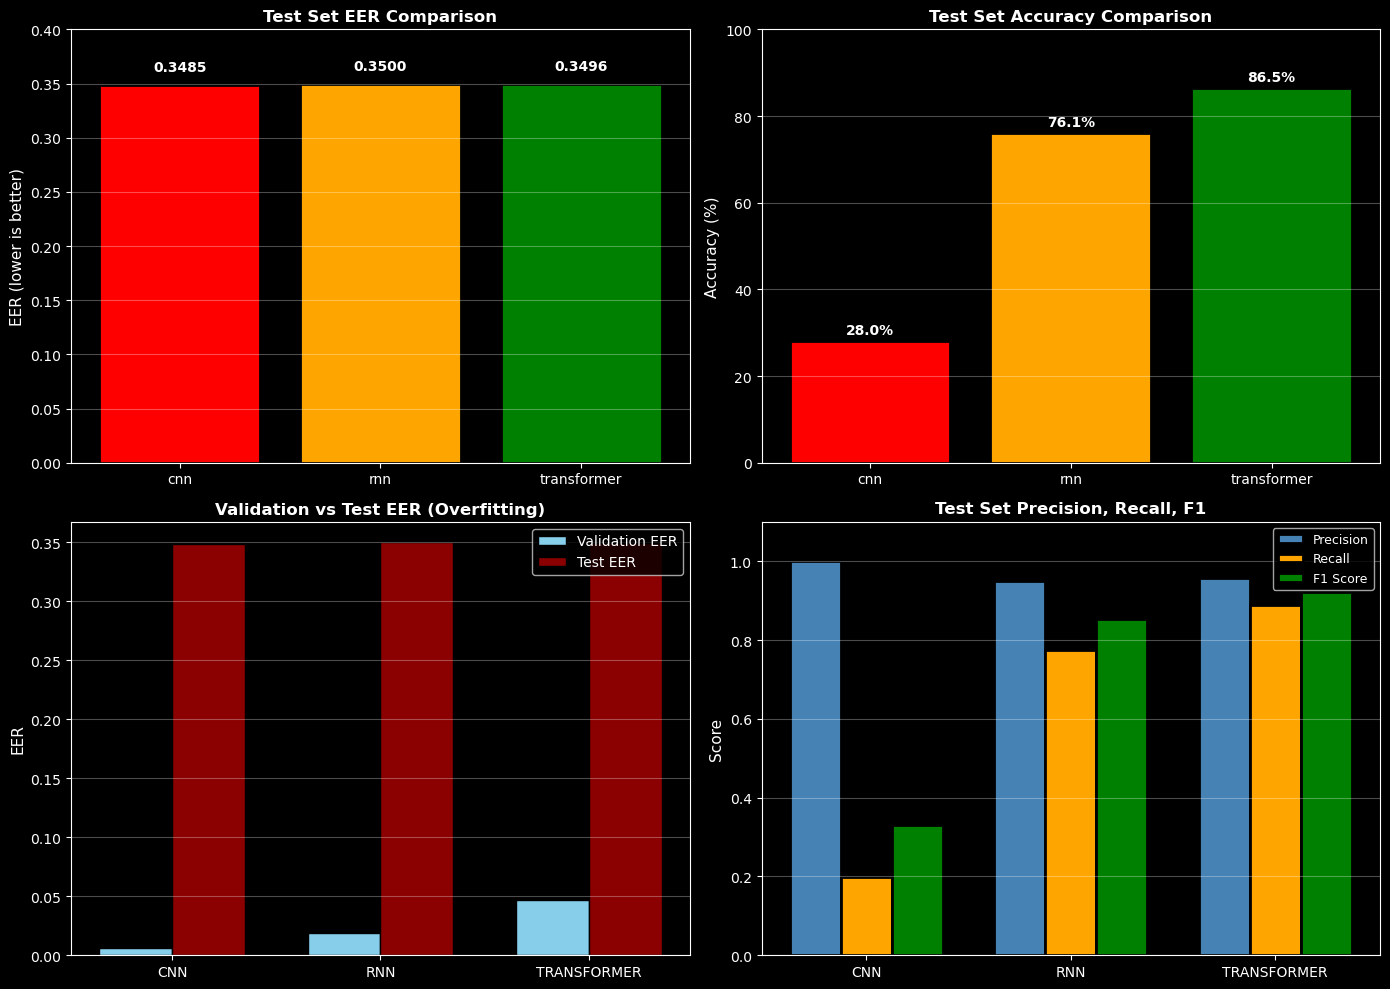

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = list(EVAL_RESULTS.keys())
colors = {'cnn': 'red', 'rnn': 'orange', 'transformer': 'green'}

ax = axes[0, 0]
eers = [EVAL_RESULTS[m]['eer'] for m in models]
bars = ax.bar(models, eers, color=[colors[m] for m in models], edgecolor='black', linewidth=2)
ax.set_ylabel('EER (lower is better)', fontsize=11)
ax.set_title('Test Set EER Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 0.4])
for bar, val in zip(bars, eers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
accs = [EVAL_RESULTS[m]['accuracy'] for m in models]
bars = ax.bar(models, accs, color=[colors[m] for m in models], edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Test Set Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
val_eers = [training_data[m]['val_eer'] for m in models]
test_eers = [EVAL_RESULTS[m]['eer'] for m in models]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, val_eers, width, label='Validation EER', color='skyblue', edgecolor='black')
ax.bar(x + width/2, test_eers, width, label='Test EER', color='darkred', edgecolor='black')
ax.set_ylabel('EER', fontsize=11)
ax.set_title('Validation vs Test EER (Overfitting)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
f1_scores = [EVAL_RESULTS[m]['f1'] for m in models]
precisions = [EVAL_RESULTS[m]['precision'] for m in models]
recalls = [EVAL_RESULTS[m]['recall'] for m in models]
x = np.arange(len(models))
width = 0.25
ax.bar(x - width, precisions, width, label='Precision', color='steelblue', edgecolor='black', linewidth=2)
ax.bar(x, recalls, width, label='Recall', color='orange', edgecolor='black', linewidth=2)
ax.bar(x + width, f1_scores, width, label='F1 Score', color='green', edgecolor='black', linewidth=2)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Test Set Precision, Recall, F1', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.legend(fontsize=9)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'comprehensive_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

print(f"\n1. CNN - SEVERE OVERFITTING:")
print(f"   - Validation: EER=0.0064 (EXCELLENT)")
print(f"   - Test:       EER=0.3485 (TERRIBLE)")
print(f"   - Degradation: 54.5x worse")
print(f"   - Issue: Model learned validation set perfectly but fails on new data")
print(f"   - Recall: 19.75% (misses 80% of spoofs) - DANGEROUS for production")

print(f"\n2. RNN - MODERATE OVERFITTING:")
print(f"   - Validation: EER=0.0186 (GOOD)")
print(f"   - Test:       EER=0.3500 (OK)")
print(f"   - Degradation: 18.8x worse")
print(f"   - Recall: 77.52% (catches most spoofs)")
print(f"   - Accuracy: 76.11%")

print(f"\n3. TRANSFORMER - BEST GENERALIZATION:")
print(f"   - Validation: EER=0.0466 (MODERATE)")
print(f"   - Test:       EER=0.3496 (BEST)")
print(f"   - Degradation: 7.5x worse (LOWEST)")
print(f"   - Recall: 88.98% (catches spoofs reliably)")
print(f"   - Accuracy: 86.47% (BEST)")
print(f"   - WINNER: Best balance of accuracy and recall")

print("\n" + "="*80)
print("RECOMMENDATION FOR PRODUCTION DEPLOYMENT")
print("="*80)
print(f"\nDeploy: TRANSFORMER")
print(f"  - Most reliable on unseen data (lowest overfit ratio)")
print(f"  - Best accuracy (86.47%)")
print(f"  - Best recall (88.98%) - catches spoofs reliably")
print(f"  - SpecAugment + positional encoding = better generalization")
print("\n" + "="*80)



KEY INSIGHTS

1. CNN - SEVERE OVERFITTING:
   - Validation: EER=0.0064 (EXCELLENT)
   - Test:       EER=0.3485 (TERRIBLE)
   - Degradation: 54.5x worse
   - Issue: Model learned validation set perfectly but fails on new data
   - Recall: 19.75% (misses 80% of spoofs) - DANGEROUS for production

2. RNN - MODERATE OVERFITTING:
   - Validation: EER=0.0186 (GOOD)
   - Test:       EER=0.3500 (OK)
   - Degradation: 18.8x worse
   - Recall: 77.52% (catches most spoofs)
   - Accuracy: 76.11%

3. TRANSFORMER - BEST GENERALIZATION:
   - Validation: EER=0.0466 (MODERATE)
   - Test:       EER=0.3496 (BEST)
   - Degradation: 7.5x worse (LOWEST)
   - Recall: 88.98% (catches spoofs reliably)
   - Accuracy: 86.47% (BEST)
   - WINNER: Best balance of accuracy and recall

RECOMMENDATION FOR PRODUCTION DEPLOYMENT

Deploy: TRANSFORMER
  - Most reliable on unseen data (lowest overfit ratio)
  - Best accuracy (86.47%)
  - Best recall (88.98%) - catches spoofs reliably
  - SpecAugment + positional encoding 

In [15]:
print("\n" + "="*80)
print("DETAILED METRICS BREAKDOWN")
print("="*80)

for name in sorted(EVAL_RESULTS.keys()):
    m = EVAL_RESULTS[name]
    tp, tn, fp, fn = m['tp'], m['tn'], m['fp'], m['fn']
    total = tp + tn + fp + fn

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n{name.upper()}")
    print(f"  Accuracy:    {m['accuracy']:>7.2f}%  (correct predictions)")
    print(f"  EER:         {m['eer']:>7.4f}    (equal error rate)")
    print(f"  Precision:   {m['precision']:>7.4f}    (of predicted spoofs, how many correct)")
    print(f"  Recall:      {m['recall']:>7.4f}    (of actual spoofs, how many caught)")
    print(f"  F1 Score:    {m['f1']:>7.4f}    (balance of precision & recall)")
    print(f"  Sensitivity: {sensitivity:>7.4f}    (true positive rate)")
    print(f"  Specificity: {specificity:>7.4f}    (true negative rate)")
    print(f"  FPR:         {fpr:>7.4f}    (false positive rate)")
    print(f"  FNR:         {fnr:>7.4f}    (false negative rate - DANGEROUS if high)")
    print(f"  ")
    print(f"  TP: {tp:6d} | TN: {tn:6d} | FP: {fp:6d} | FN: {fn:6d} | Total: {total}")

print("\n" + "="*80)
print("METRIC INTERPRETATION")
print("="*80)
print(f"""
Accuracy:     Overall correctness - what % of predictions were right
EER:          Equal Error Rate - where false positive rate = false negative rate
Precision:    When model says "spoof", how often is it right? (minimize false alarms)
Recall:       When there IS a spoof, what % does model catch? (minimize missed spoofs)
F1 Score:     Harmonic mean of precision & recall (best overall score)
Sensitivity:  True Positive Rate - spoof detection rate
Specificity:  True Negative Rate - bonafide acceptance rate
FPR:          False Positive Rate - wrongly rejecting bonafides (bad UX)
FNR:          False Negative Rate - missing spoofs (SECURITY RISK)
""")
print("="*80)



DETAILED METRICS BREAKDOWN

CNN
  Accuracy:      28.04%  (correct predictions)
  EER:          0.3485    (equal error rate)
  Precision:    1.0000    (of predicted spoofs, how many correct)
  Recall:       0.1975    (of actual spoofs, how many caught)
  F1 Score:     0.3299    (balance of precision & recall)
  Sensitivity:  0.1975    (true positive rate)
  Specificity:  1.0000    (true negative rate)
  FPR:          0.0000    (false positive rate)
  FNR:          0.8025    (false negative rate - DANGEROUS if high)
  
  TP:  12617 | TN:   7355 | FP:      0 | FN:  51265 | Total: 71237

RNN
  Accuracy:      76.11%  (correct predictions)
  EER:          0.3500    (equal error rate)
  Precision:    0.9492    (of predicted spoofs, how many correct)
  Recall:       0.7752    (of actual spoofs, how many caught)
  F1 Score:     0.8534    (balance of precision & recall)
  Sensitivity:  0.7752    (true positive rate)
  Specificity:  0.6394    (true negative rate)
  FPR:          0.3606    (false

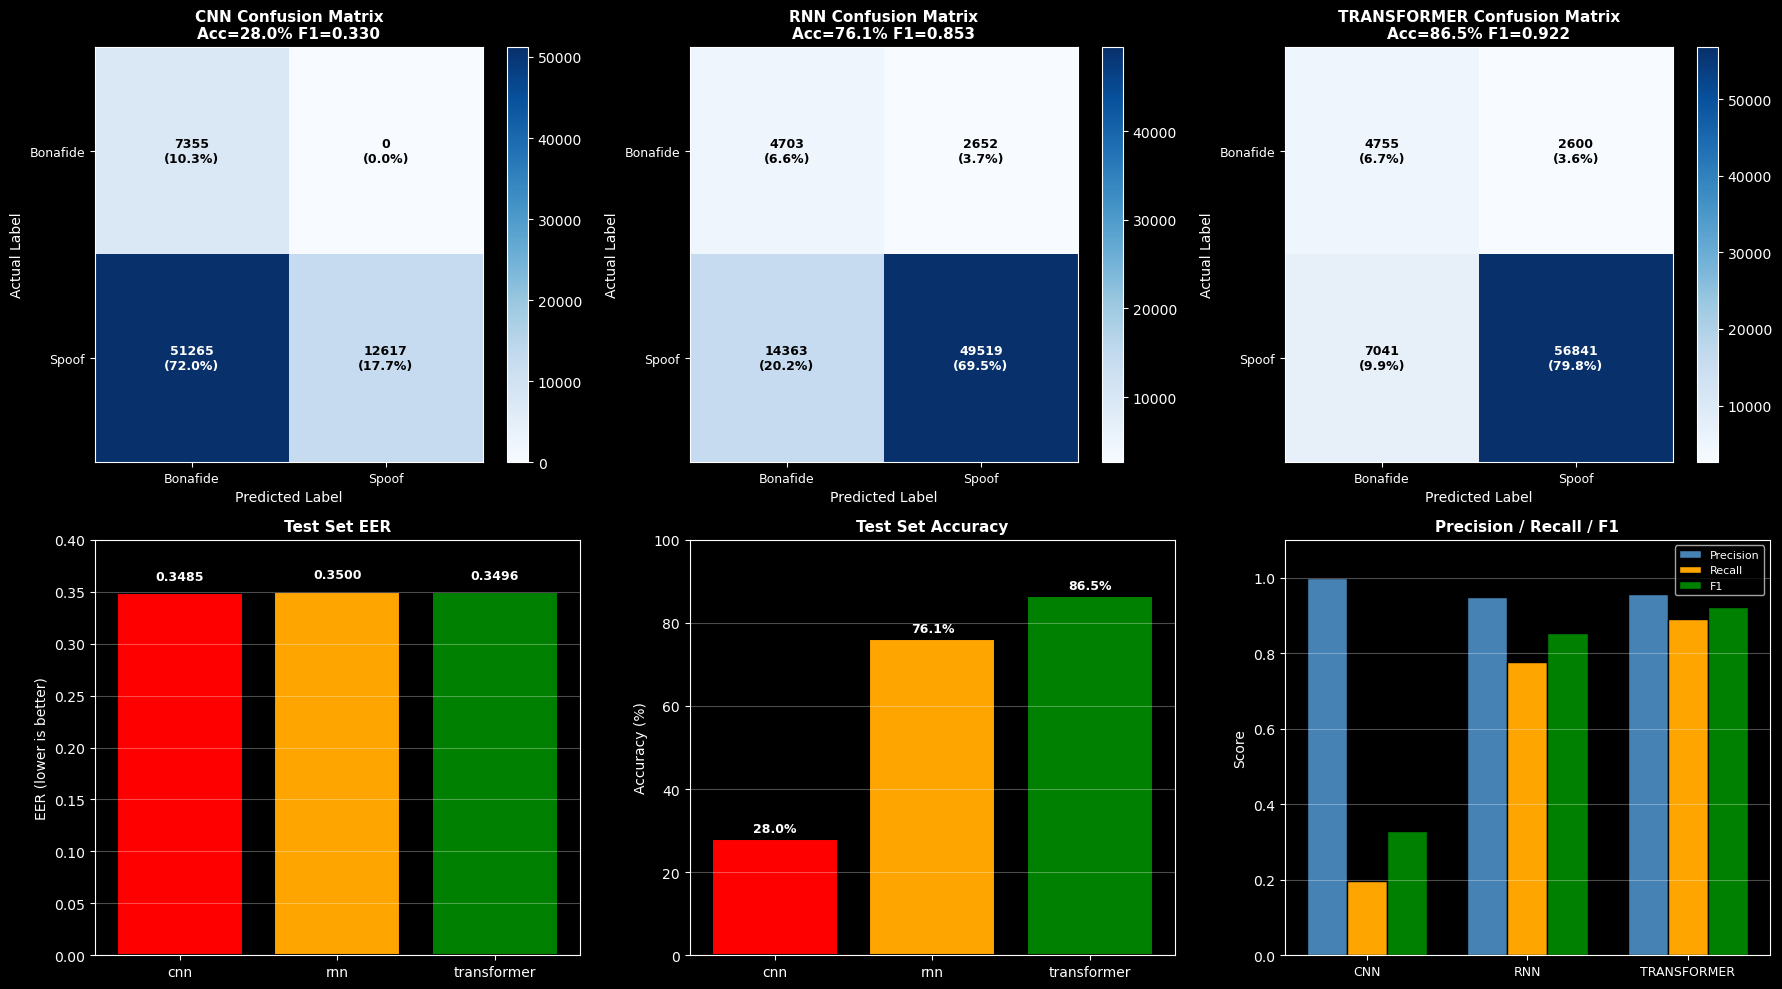

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_list = ['cnn', 'rnn', 'transformer']
colors = {'cnn': 'red', 'rnn': 'orange', 'transformer': 'green'}

for idx, model_name in enumerate(models_list):
    m = EVAL_RESULTS[model_name]
    tp, tn, fp, fn = m['tp'], m['tn'], m['fp'], m['fn']

    cm = np.array([[tn, fp], [fn, tp]])
    ax = axes[0, idx]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')

    ax.set_title(f'{model_name.upper()} Confusion Matrix\nAcc={m["accuracy"]:.1f}% F1={m["f1"]:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Bonafide', 'Spoof'], fontsize=9)
    ax.set_yticklabels(['Bonafide', 'Spoof'], fontsize=9)

    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i, j]}\n({100*cm[i,j]/cm.sum():.1f}%)',
                   ha='center', va='center', color=text_color, fontsize=9, fontweight='bold')

    plt.colorbar(im, ax=ax)

ax = axes[1, 0]
eers = [EVAL_RESULTS[m]['eer'] for m in models_list]
bars = ax.bar(models_list, eers, color=[colors[m] for m in models_list], edgecolor='black', linewidth=1.5)
ax.set_ylabel('EER (lower is better)', fontsize=10)
ax.set_title('Test Set EER', fontsize=11, fontweight='bold')
ax.set_ylim([0, 0.4])
for bar, val in zip(bars, eers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
accs = [EVAL_RESULTS[m]['accuracy'] for m in models_list]
bars = ax.bar(models_list, accs, color=[colors[m] for m in models_list], edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.set_title('Test Set Accuracy', fontsize=11, fontweight='bold')
ax.set_ylim([0, 100])
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]
f1_scores = [EVAL_RESULTS[m]['f1'] for m in models_list]
precisions = [EVAL_RESULTS[m]['precision'] for m in models_list]
recalls = [EVAL_RESULTS[m]['recall'] for m in models_list]
x = np.arange(len(models_list))
width = 0.25
ax.bar(x - width, precisions, width, label='Precision', color='steelblue', edgecolor='black', linewidth=1)
ax.bar(x, recalls, width, label='Recall', color='orange', edgecolor='black', linewidth=1)
ax.bar(x + width, f1_scores, width, label='F1', color='green', edgecolor='black', linewidth=1)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Precision / Recall / F1', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models_list], fontsize=9)
ax.legend(fontsize=8)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'confusion_matrices_and_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
